<h1>시계열 데이터</h1>

In [1]:
import pandas as pd

In [2]:
# 데이터 출처) http://finance.yahoo.com/quote/GOOG/history?ltr=1
timeSeries = pd.read_csv('./../data/time_series.csv')
display(timeSeries.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       254 non-null    object 
 1   Open       254 non-null    float64
 2   High       254 non-null    float64
 3   Low        254 non-null    float64
 4   Close      254 non-null    float64
 5   Adj Close  254 non-null    float64
 6   Volume     254 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 14.0+ KB


None

In [3]:
timeSeries['new_Date'] = pd.to_datetime(timeSeries['Date'])

In [4]:
timeSeries=timeSeries.sort_values(by='new_Date', ascending=False)
timeSeries.head()

,Date,Open,High,Low,Close,Adj Close,Volume,new_Date
253,2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03-14
252,2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03-13
251,2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03-10
250,2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03-09
249,2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03-08


In [5]:
timeSeries.set_index('new_Date', inplace=True, drop=False)
timeSeries.drop('Date', axis=1, inplace=True)

In [6]:
timeSeries.head(10)

,Open,High,Low,Close,Adj Close,Volume,new_Date
new_Date,,,,,,,
2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03-14
2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03-13
2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03-10
2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03-09
2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03-08
2023-03-07,95.419998,96.089996,93.844002,94.169998,94.169998,24101500,2023-03-07
2023-03-06,94.360001,96.300003,94.300003,95.580002,95.580002,28288200,2023-03-06
2023-03-03,92.739998,94.110001,92.660004,94.019997,94.019997,30220900,2023-03-03
2023-03-02,89.860001,92.480003,89.769997,92.309998,92.309998,23328600,2023-03-02


<h6><font color="green">to_period 사용해보기</font></h6>

In [7]:
# to_period() 일정한 기간을 나타내는 Period 객체 생성
pr_month = timeSeries.index.to_period(freq='M')
print(pr_month)

PeriodIndex(['2023-03', '2023-03', '2023-03', '2023-03', '2023-03', '2023-03',
             '2023-03', '2023-03', '2023-03', '2023-03',
             ...
             '2022-03', '2022-03', '2022-03', '2022-03', '2022-03', '2022-03',
             '2022-03', '2022-03', '2022-03', '2022-03'],
            dtype='period[M]', name='new_Date', length=254)


In [8]:
timeSeries['pr_month']=pr_month
timeSeries.head()

,Open,High,Low,Close,Adj Close,Volume,new_Date,pr_month
new_Date,,,,,,,,
2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03-14,2023-03
2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03-13,2023-03
2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03-10,2023-03
2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03-09,2023-03
2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03-08,2023-03


<h6><font color="green">dt 속성을 사용한 데이터 분리</font></h6>

In [9]:
timeSeries['year'] = timeSeries['new_Date'].dt.year
timeSeries['month'] = timeSeries['new_Date'].dt.month
timeSeries['day'] = timeSeries['new_Date'].dt.day

In [10]:
timeSeries.drop('new_Date', axis=1, inplace=True)
timeSeries.index.name='Date'
timeSeries.head()

,Open,High,Low,Close,Adj Close,Volume,pr_month,year,month,day
Date,,,,,,,,,,
2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03,2023,3,14
2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03,2023,3,13
2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03,2023,3,10
2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03,2023,3,9
2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03,2023,3,8


<h6><font color="green">날짜 색인 활용하기</font></h6>

In [11]:
year_data = timeSeries.loc['2023']
display(year_data.head())

,Open,High,Low,Close,Adj Close,Volume,pr_month,year,month,day
Date,,,,,,,,,,
2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03,2023,3,14
2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03,2023,3,13
2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03,2023,3,10
2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03,2023,3,9
2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03,2023,3,8


In [12]:
ym_data = timeSeries.loc['2023-03']
display(ym_data)

,Open,High,Low,Close,Adj Close,Volume,pr_month,year,month,day
Date,,,,,,,,,,
2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03,2023,3,14
2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03,2023,3,13
2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03,2023,3,10
2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03,2023,3,9
2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03,2023,3,8
2023-03-07,95.419998,96.089996,93.844002,94.169998,94.169998,24101500,2023-03,2023,3,7
2023-03-06,94.360001,96.300003,94.300003,95.580002,95.580002,28288200,2023-03,2023,3,6
2023-03-03,92.739998,94.110001,92.660004,94.019997,94.019997,30220900,2023-03,2023,3,3
2023-03-02,89.860001,92.480003,89.769997,92.309998,92.309998,23328600,2023-03,2023,3,2


In [13]:
df_ym_cols = timeSeries.loc['2023-03', 'Open':'Low']    # 열 범위 슬라이싱
display(df_ym_cols)

,Open,High,Low
Date,,,
2023-03-14,93.070000,94.830002,92.779999
2023-03-13,90.565002,93.080002,89.940002
2023-03-10,92.500000,93.180000,90.800003
2023-03-09,94.489998,95.919998,92.355003
2023-03-08,94.404999,96.239998,94.404999
2023-03-07,95.419998,96.089996,93.844002
2023-03-06,94.360001,96.300003,94.300003
2023-03-03,92.739998,94.110001,92.660004
2023-03-02,89.860001,92.480003,89.769997


In [14]:
date_range = timeSeries.loc['2023-02-01':'2023-02-03', :]
display(date_range)

KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is not allowed.'

In [15]:
today = pd.to_datetime('2023-03-15')            # 기준일 생성
timeSeries['time_delta'] = today - timeSeries.index             # 날짜 차이 계산
display(timeSeries.head())

,Open,High,Low,Close,Adj Close,Volume,pr_month,year,month,day,time_delta
Date,,,,,,,,,,,
2023-03-14,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03,2023,3,14,1 days
2023-03-13,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03,2023,3,13,2 days
2023-03-10,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03,2023,3,10,5 days
2023-03-09,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03,2023,3,9,6 days
2023-03-08,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03,2023,3,8,7 days


In [16]:
newTimeSeries=timeSeries.copy()
newTimeSeries.set_index('time_delta', inplace=True) 
frame_range = newTimeSeries['1 days':'100 days']
display(frame_range.head())

,Open,High,Low,Close,Adj Close,Volume,pr_month,year,month,day
time_delta,,,,,,,,,,
1 days,93.070000,94.830002,92.779999,94.250000,94.250000,32284100,2023-03,2023,3,14
2 days,90.565002,93.080002,89.940002,91.660004,91.660004,31508600,2023-03,2023,3,13
5 days,92.500000,93.180000,90.800003,91.010002,91.010002,32831700,2023-03,2023,3,10
6 days,94.489998,95.919998,92.355003,92.660004,92.660004,24438900,2023-03,2023,3,9
7 days,94.404999,96.239998,94.404999,94.650002,94.650002,25395200,2023-03,2023,3,8


In [17]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

Text(0.5, 1.0, '장 마감 꺽은 선')

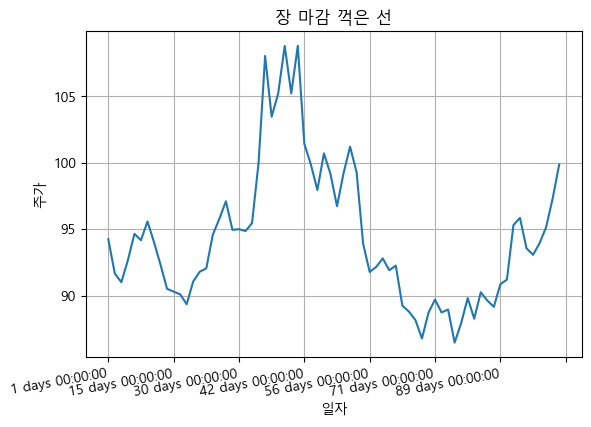

In [18]:
frame_range['Close'].plot(kind='line',grid=True, \
                rot=10, use_index=True)
plt.xlabel('일자')
plt.ylabel('주가')
plt.title('장 마감 꺽은 선')